# Current WebArena Example Analysis

This notebook is the current execution and analysis surface for the local WebArena-Verified thesis prototype.

It covers all currently available example paths:

- Service probe: `shopping`, `shopping_admin`, `reddit`, `gitlab`, `wikipedia`
- Official hardcoded tasks: `shopping` 118, `shopping_admin` 157, `reddit` 27, `gitlab` 44
- Planner preview: all enabled local sites except Map
- H/k orchestrator: current local runs for `gitlab`, `shopping`, `shopping_admin`, `reddit`, and `wikipedia`
- Exploratory longer GitLab candidate: Task 105

Scope note: Reddit is now executable in the H/k logging pipeline with the current deterministic retrieved-data response. Wikipedia is executable as a direct H/k probe, but has no official score in this local setup. GitLab Task 105 is useful as a longer-task candidate, but currently fails official evaluation because the expected repository URL returns 404 in the local demo GitLab instance.

In [1]:
from pathlib import Path
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

OFFICIAL_REPO = ROOT / 'external' / 'webarena-verified'
SWEEP_BASE = OFFICIAL_REPO / 'output' / 'hk-sweep'
SERVICE_SUMMARY = OFFICIAL_REPO / 'output' / 'service-probe' / 'summary.json'
HARDCODED_SUMMARY = OFFICIAL_REPO / 'output' / 'hardcoded-tasks' / 'summary.json'
PLANNER_PREVIEW_SUMMARY = OFFICIAL_REPO / 'output' / 'planner-preview' / 'summary.json'

pd.set_option('display.max_colwidth', 180)
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

SITE_ORDER = ['shopping', 'shopping_admin', 'reddit', 'gitlab', 'wikipedia']
OFFICIAL_HK_SITES = ['shopping', 'shopping_admin', 'reddit', 'gitlab']


def read_json(path: Path):
    return json.loads(path.read_text())


def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.DataFrame([json.loads(line) for line in path.read_text().splitlines() if line.strip()])


def artifact_paths(output_dir: str) -> dict[str, Path]:
    base = Path(output_dir)
    return {
        'plan': base / 'plan.json',
        'step_trace': base / 'step_trace.jsonl',
        'evaluator_signals': base / 'evaluator_signals.jsonl',
        'controller_decisions': base / 'controller_decisions.jsonl',
        'run_summary': base / 'run_summary.json',
        'eval_result': base / 'eval_result.json',
    }


def show_bar(ax, values, title, ylabel=None, xlabel=None, ylim=None, color='#4c78a8'):
    values.plot(kind='bar', ax=ax, color=color, rot=35)
    ax.set_title(title)
    ax.set_ylabel(ylabel or '')
    ax.set_xlabel(xlabel or '')
    if ylim:
        ax.set_ylim(*ylim)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3g', padding=3)

ROOT, OFFICIAL_REPO

## Run Cells

These cells make the notebook executable. Keep the toggles at `False` when you only want to inspect existing artifacts. Set them to `True` to regenerate the corresponding group.

In [2]:
MODEL = 'gemma4:26b'
RUN_SERVICE_AND_SUPPORTING = False
RUN_STANDARD_HK = False
RUN_LONG_GITLAB_CANDIDATE = False

SUPPORTING_COMMANDS = [
    ['uv', 'run', 'python', 'scripts/run_services_probe.py', '--sites', 'shopping', 'shopping_admin', 'reddit', 'gitlab', 'wikipedia'],
    ['uv', 'run', 'python', 'scripts/run_hardcoded_tasks.py', '--sites', 'shopping', 'shopping_admin', 'reddit', 'gitlab'],
    ['uv', 'run', 'python', 'scripts/preview_planner.py', '--planner-mode', 'ollama', '--model', MODEL, '--sites', 'shopping', 'shopping_admin', 'reddit', 'gitlab', 'wikipedia', '--h', '0'],
]

STANDARD_HK_COMMANDS = [
    ['uv', 'run', 'python', 'scripts/run_hk_sweep.py', '--site', 'gitlab', '--output-root', 'output/hk-sweep/gitlab', '--hs', '0', '1', '2', '--ks', '1', '2', '--model', MODEL],
    ['uv', 'run', 'python', 'scripts/run_hk_sweep.py', '--site', 'shopping', '--output-root', 'output/hk-sweep/shopping', '--hs', '0', '--ks', '1', '2', '--model', MODEL],
    ['uv', 'run', 'python', 'scripts/run_hk_sweep.py', '--site', 'shopping_admin', '--output-root', 'output/hk-sweep/shopping_admin', '--hs', '0', '1', '2', '--ks', '1', '2', '--model', MODEL],
    ['uv', 'run', 'python', 'scripts/run_hk_sweep.py', '--site', 'reddit', '--output-root', 'output/hk-sweep/reddit', '--hs', '0', '1', '2', '--ks', '1', '2', '--model', MODEL],
    ['uv', 'run', 'python', 'scripts/run_hk_sweep.py', '--site', 'wikipedia', '--output-root', 'output/hk-sweep/wikipedia', '--hs', '0', '1', '2', '--ks', '1', '2', '--model', MODEL, '--skip-eval'],
]

LONG_GITLAB_COMMAND = [
    'uv', 'run', 'python', 'scripts/run_hk_sweep.py',
    '--site', 'gitlab', '--task-id', '105',
    '--output-root', 'output/hk-sweep/gitlab-long-task105',
    '--hs', '0', '1', '2', '--ks', '1', '2', '--model', MODEL,
]

for enabled, commands, label in [
    (RUN_SERVICE_AND_SUPPORTING, SUPPORTING_COMMANDS, 'supporting examples'),
    (RUN_STANDARD_HK, STANDARD_HK_COMMANDS, 'standard H/k examples'),
    (RUN_LONG_GITLAB_CANDIDATE, [LONG_GITLAB_COMMAND], 'long GitLab candidate'),
]:
    if enabled:
        for command in commands:
            print('$', ' '.join(command))
            subprocess.run(command, cwd=ROOT, check=True)
    else:
        print(f'{label} skipped. Commands available:')
        for command in commands:
            print(' ', ' '.join(command))

supporting examples skipped. Commands available:
  uv run python scripts/run_services_probe.py --sites shopping shopping_admin reddit gitlab wikipedia
  uv run python scripts/run_hardcoded_tasks.py --sites shopping shopping_admin reddit gitlab
  uv run python scripts/preview_planner.py --planner-mode ollama --model gemma4:26b --sites shopping shopping_admin reddit gitlab wikipedia --h 0
standard H/k examples skipped. Commands available:
  uv run python scripts/run_hk_sweep.py --site gitlab --output-root output/hk-sweep/gitlab --hs 0 1 2 --ks 1 2 --model gemma4:26b
  uv run python scripts/run_hk_sweep.py --site shopping --output-root output/hk-sweep/shopping --hs 0 --ks 1 2 --model gemma4:26b
  uv run python scripts/run_hk_sweep.py --site shopping_admin --output-root output/hk-sweep/shopping_admin --hs 0 1 2 --ks 1 2 --model gemma4:26b
  uv run python scripts/run_hk_sweep.py --site reddit --output-root output/hk-sweep/reddit --hs 0 1 2 --ks 1 2 --model gemma4:26b
  uv run python scripts

## Load Current Artifacts

In [3]:
service_df = pd.DataFrame(read_json(SERVICE_SUMMARY).get('results', [])) if SERVICE_SUMMARY.exists() else pd.DataFrame()
hardcoded_df = pd.DataFrame(read_json(HARDCODED_SUMMARY).get('results', [])) if HARDCODED_SUMMARY.exists() else pd.DataFrame()
preview_df = pd.DataFrame(read_json(PLANNER_PREVIEW_SUMMARY).get('results', [])) if PLANNER_PREVIEW_SUMMARY.exists() else pd.DataFrame()

hk_rows = []
for path in sorted(SWEEP_BASE.glob('*/summary.json')):
    summary = read_json(path)
    for row in summary.get('rows', []):
        row = dict(row)
        row['summary_file'] = str(path)
        row['sweep_name'] = path.parent.name
        hk_rows.append(row)
hk_df = pd.DataFrame(hk_rows)
if not hk_df.empty:
    hk_df['runtime_s'] = hk_df['total_runtime_ms'] / 1000
    hk_df['score'] = pd.to_numeric(hk_df['score'], errors='coerce')
    hk_df['task_label'] = hk_df['task_id'].fillna('direct').astype(str)
    hk_df['run_label'] = hk_df['sweep_name'] + ' T' + hk_df['task_label'] + ' H' + hk_df['h'].astype(str) + '/k' + hk_df['k'].astype(str)
    hk_df['is_long_gitlab_candidate'] = (hk_df['site'] == 'gitlab') & (hk_df['task_id'] == 105)
    hk_df['has_official_score'] = hk_df['score'].notna()
    hk_df = hk_df.sort_values(['sweep_name', 'site', 'task_id', 'h', 'k']).reset_index(drop=True)

standard_hk_df = hk_df[~hk_df.get('is_long_gitlab_candidate', pd.Series(dtype=bool))].copy() if not hk_df.empty else pd.DataFrame()
long_gitlab_df = hk_df[hk_df.get('is_long_gitlab_candidate', pd.Series(dtype=bool))].copy() if not hk_df.empty else pd.DataFrame()

print('service rows:', len(service_df))
print('hardcoded rows:', len(hardcoded_df))
print('planner preview rows:', len(preview_df))
print('H/k rows:', len(hk_df))

service rows: 5
hardcoded rows: 5
planner preview rows: 5
H/k rows: 32


## Coverage Overview

,site,service_probe,hardcoded_official_task,planner_preview,hk_orchestrator
0,shopping,True,True,True,True
1,shopping_admin,True,True,True,True
2,reddit,True,True,True,True
3,gitlab,True,True,True,True
4,wikipedia,True,True,True,True


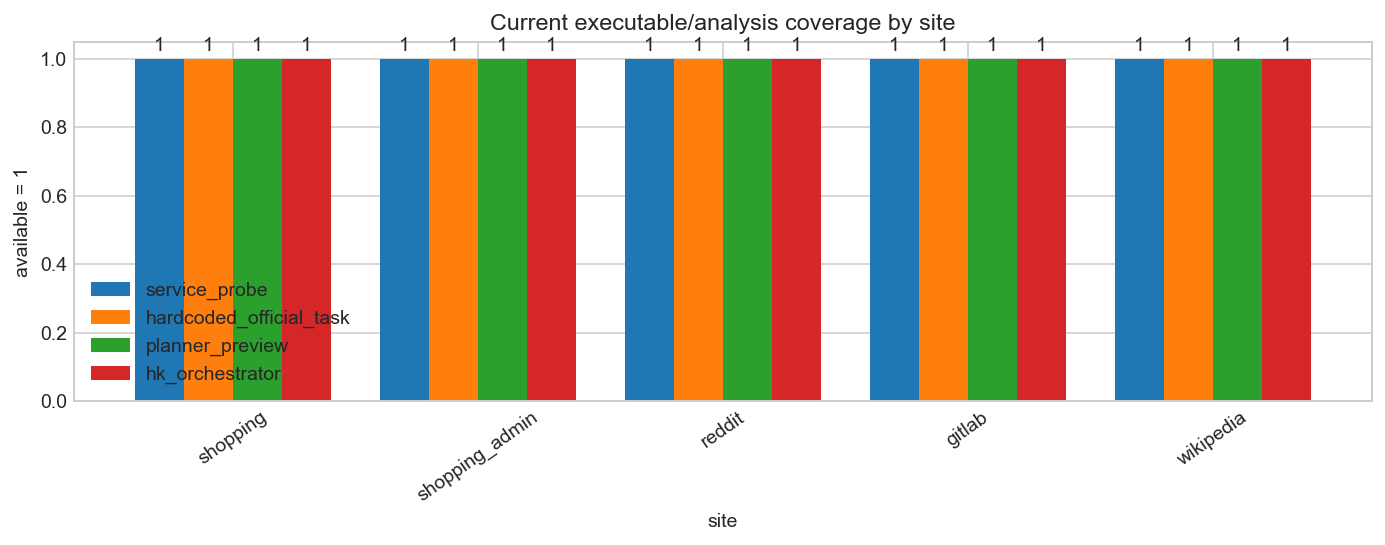

In [4]:
coverage = pd.DataFrame({'site': SITE_ORDER})
coverage['service_probe'] = coverage['site'].isin(service_df.get('site', pd.Series(dtype=str)))
coverage['hardcoded_official_task'] = coverage['site'].isin(hardcoded_df.get('site', pd.Series(dtype=str)))
coverage['planner_preview'] = coverage['site'].isin(preview_df.get('site', pd.Series(dtype=str)))
coverage['hk_orchestrator'] = coverage['site'].isin(standard_hk_df.get('site', pd.Series(dtype=str)))
display(coverage)

fig, ax = plt.subplots(figsize=(10, 4))
coverage.set_index('site').astype(int).plot(kind='bar', ax=ax, rot=35, width=0.8)
ax.set_title('Current executable/analysis coverage by site')
ax.set_ylabel('available = 1')
ax.set_xlabel('site')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2)
plt.tight_layout()

## Service Probe Analysis

,site,status,task_id,task_type,start_url,final_url,page_title,error
0,shopping,success,118.0,NAVIGATE,http://localhost:7770,http://localhost:7770/,One Stop Market,None
1,shopping_admin,success,157.0,NAVIGATE,http://localhost:7780/admin,http://localhost:7780/admin,Magento Admin,None
2,reddit,success,27.0,RETRIEVE,http://localhost:9999,http://localhost:9999/,Postmill,None
3,gitlab,success,44.0,NAVIGATE,http://localhost:8012,http://localhost:8012/users/sign_in,Sign in · GitLab,None
4,wikipedia,success,NaN,SERVICE_PROBE,http://localhost:8888,http://localhost:8888/wikipedia_en_all_maxi_2022-05/A/User:The_other_Kiwix_guy/Landing,User:The other Kiwix guy/Landing,None


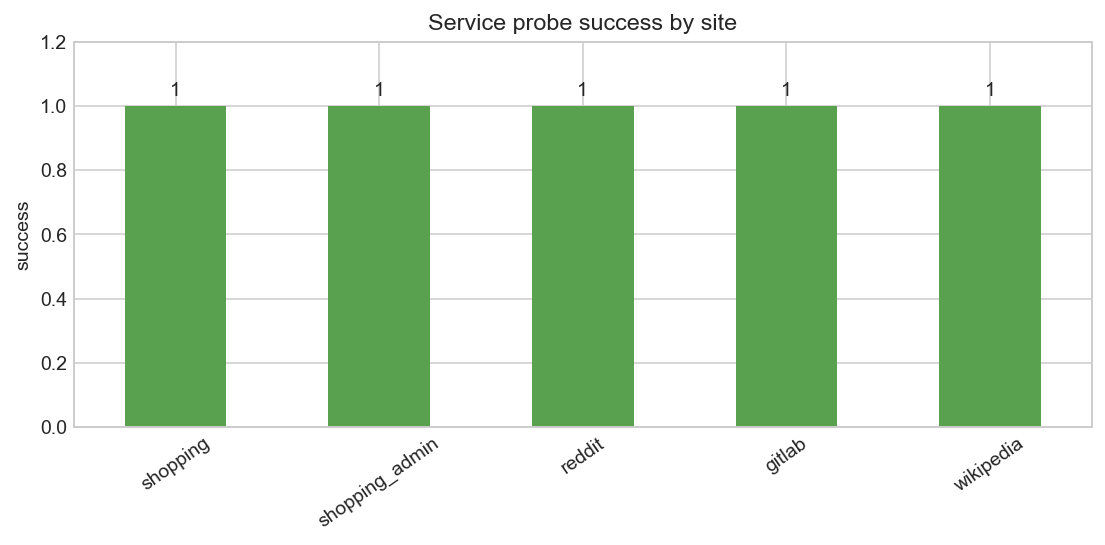

In [5]:
if service_df.empty:
    print('No service-probe summary found:', SERVICE_SUMMARY)
else:
    display(service_df[['site', 'status', 'task_id', 'task_type', 'start_url', 'final_url', 'page_title', 'error']])
    plot = service_df.assign(success_flag=(service_df['status'] == 'success').astype(int)).set_index('site').reindex(SITE_ORDER)['success_flag']
    fig, ax = plt.subplots(figsize=(8, 4))
    show_bar(ax, plot, 'Service probe success by site', ylabel='success', ylim=(0, 1.2), color='#59a14f')
    plt.tight_layout()

## Official Hardcoded Task Analysis

This includes Reddit Task 27 as the current official retrieve example.

,site,task_id,task_type,status,success,official_score,total_runtime_ms,final_url
0,shopping,118.0,NAVIGATE,success,True,1.0,5701,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...
1,shopping_admin,157.0,NAVIGATE,success,True,1.0,9248,http://localhost:7780/admin/customer/index/
2,reddit,27.0,RETRIEVE,success,True,1.0,4771,http://localhost:9999/
3,gitlab,44.0,NAVIGATE,success,True,1.0,9013,http://localhost:8012/dashboard/todos
4,wikipedia,NaN,SERVICE_PROBE,success,True,NaN,2017,http://localhost:8888/wikipedia_en_all_maxi_2022-05/A/User:The_other_Kiwix_guy/Landing


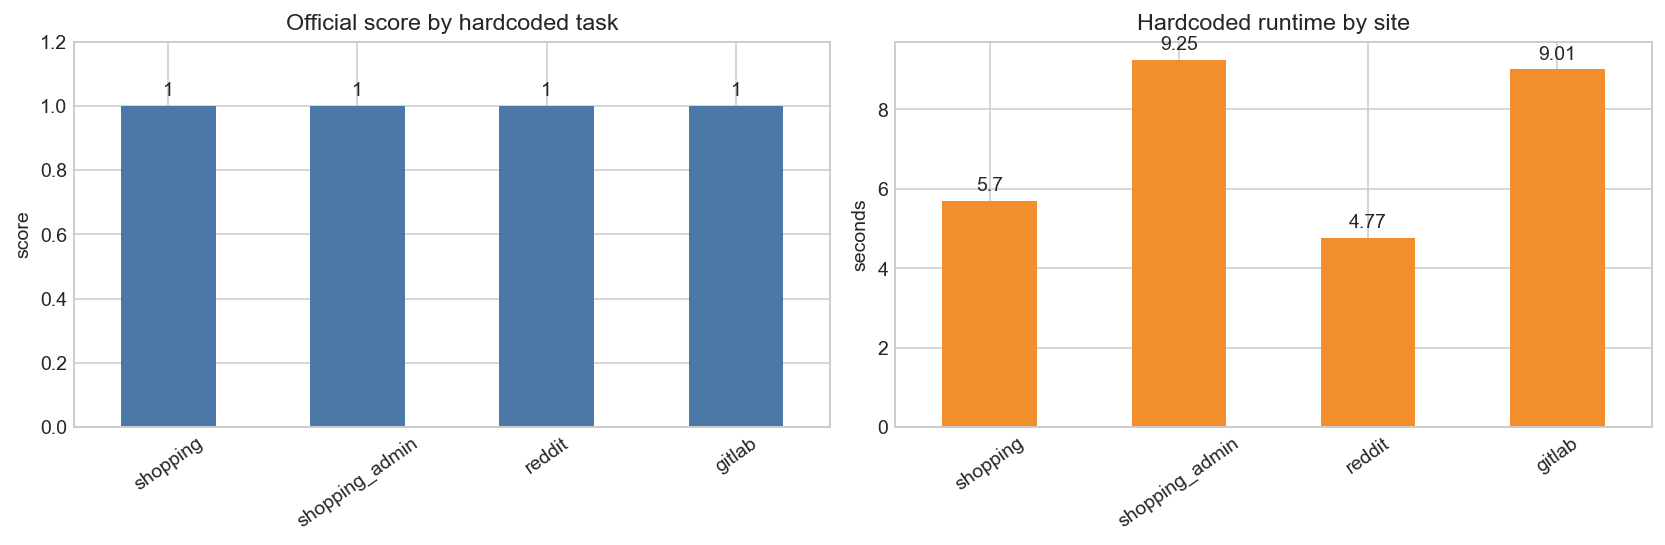

In [6]:
if hardcoded_df.empty:
    print('No hardcoded summary found:', HARDCODED_SUMMARY)
else:
    display(hardcoded_df[['site', 'task_id', 'task_type', 'status', 'success', 'official_score', 'total_runtime_ms', 'final_url']])
    hardcoded_plot = hardcoded_df.set_index('site').reindex(['shopping', 'shopping_admin', 'reddit', 'gitlab'])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    show_bar(axes[0], hardcoded_plot['official_score'], 'Official score by hardcoded task', ylabel='score', ylim=(0, 1.2), color='#4c78a8')
    show_bar(axes[1], hardcoded_plot['total_runtime_ms'] / 1000, 'Hardcoded runtime by site', ylabel='seconds', color='#f28e2b')
    plt.tight_layout()

## Planner Preview Analysis

,site,task_id,planner_mode,model_name,h,subgoal_count,warnings,output_dir
0,shopping,118.0,ollama,gemma4:26b,0,3,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/shopping/118
1,shopping_admin,157.0,ollama,gemma4:26b,0,3,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/shopping_admin/157
2,reddit,27.0,ollama,gemma4:26b,0,5,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/reddit/27
3,gitlab,44.0,ollama,gemma4:26b,0,2,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/gitlab/44
4,wikipedia,NaN,ollama,gemma4:26b,0,2,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/wikipedia/direct


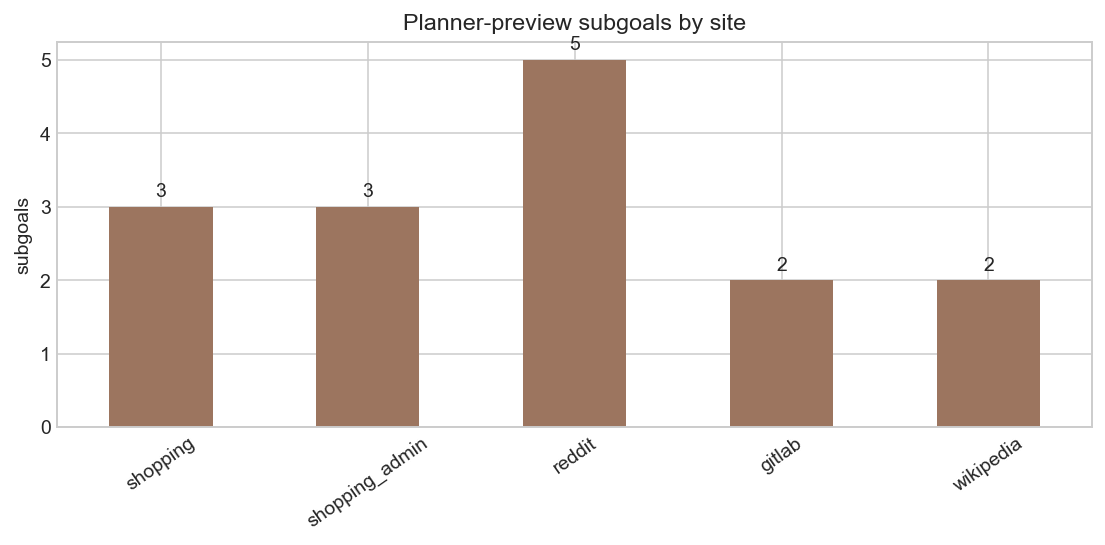

In [7]:
if preview_df.empty:
    print('No planner-preview summary found:', PLANNER_PREVIEW_SUMMARY)
else:
    display(preview_df[['site', 'task_id', 'planner_mode', 'model_name', 'h', 'subgoal_count', 'warnings', 'output_dir']])
    preview_plot = preview_df.set_index('site').reindex(SITE_ORDER)['subgoal_count']
    fig, ax = plt.subplots(figsize=(8, 4))
    show_bar(ax, preview_plot, 'Planner-preview subgoals by site', ylabel='subgoals', color='#9c755f')
    plt.tight_layout()

## Standard H/k Orchestrator Analysis

These are the current executable H/k runs for all enabled local sites. Wikipedia has no official score because it is a direct service probe without a matching official task in this local scope.

,sweep_name,site,task_id,h,k,score,success,total_steps,num_planner_calls,num_plan_subgoals_generated,total_tokens,runtime_s,final_url
0,gitlab,gitlab,44.0,0,1,1.0,True,2,1,2,1729,44.142,http://localhost:8012/dashboard/todos
1,gitlab,gitlab,44.0,0,2,1.0,True,2,1,2,1978,34.199,http://localhost:8012/dashboard/todos
2,gitlab,gitlab,44.0,1,1,1.0,True,2,2,2,4582,58.022,http://localhost:8012/dashboard/todos
3,gitlab,gitlab,44.0,1,2,1.0,True,2,2,2,3979,56.731,http://localhost:8012/dashboard/todos
4,gitlab,gitlab,44.0,2,1,1.0,True,2,1,2,1717,29.643,http://localhost:8012/dashboard/todos
5,gitlab,gitlab,44.0,2,2,1.0,True,2,1,2,3130,67.989,http://localhost:8012/dashboard/todos
12,reddit,reddit,27.0,0,1,1.0,True,1,1,5,2513,46.069,http://localhost:9999/
13,reddit,reddit,27.0,0,2,1.0,True,1,1,5,2757,50.252,http://localhost:9999/
14,reddit,reddit,27.0,1,1,1.0,True,1,1,1,2126,29.848,http://localhost:9999/
15,reddit,reddit,27.0,1,2,1.0,True,1,1,1,2001,24.398,http://localhost:9999/


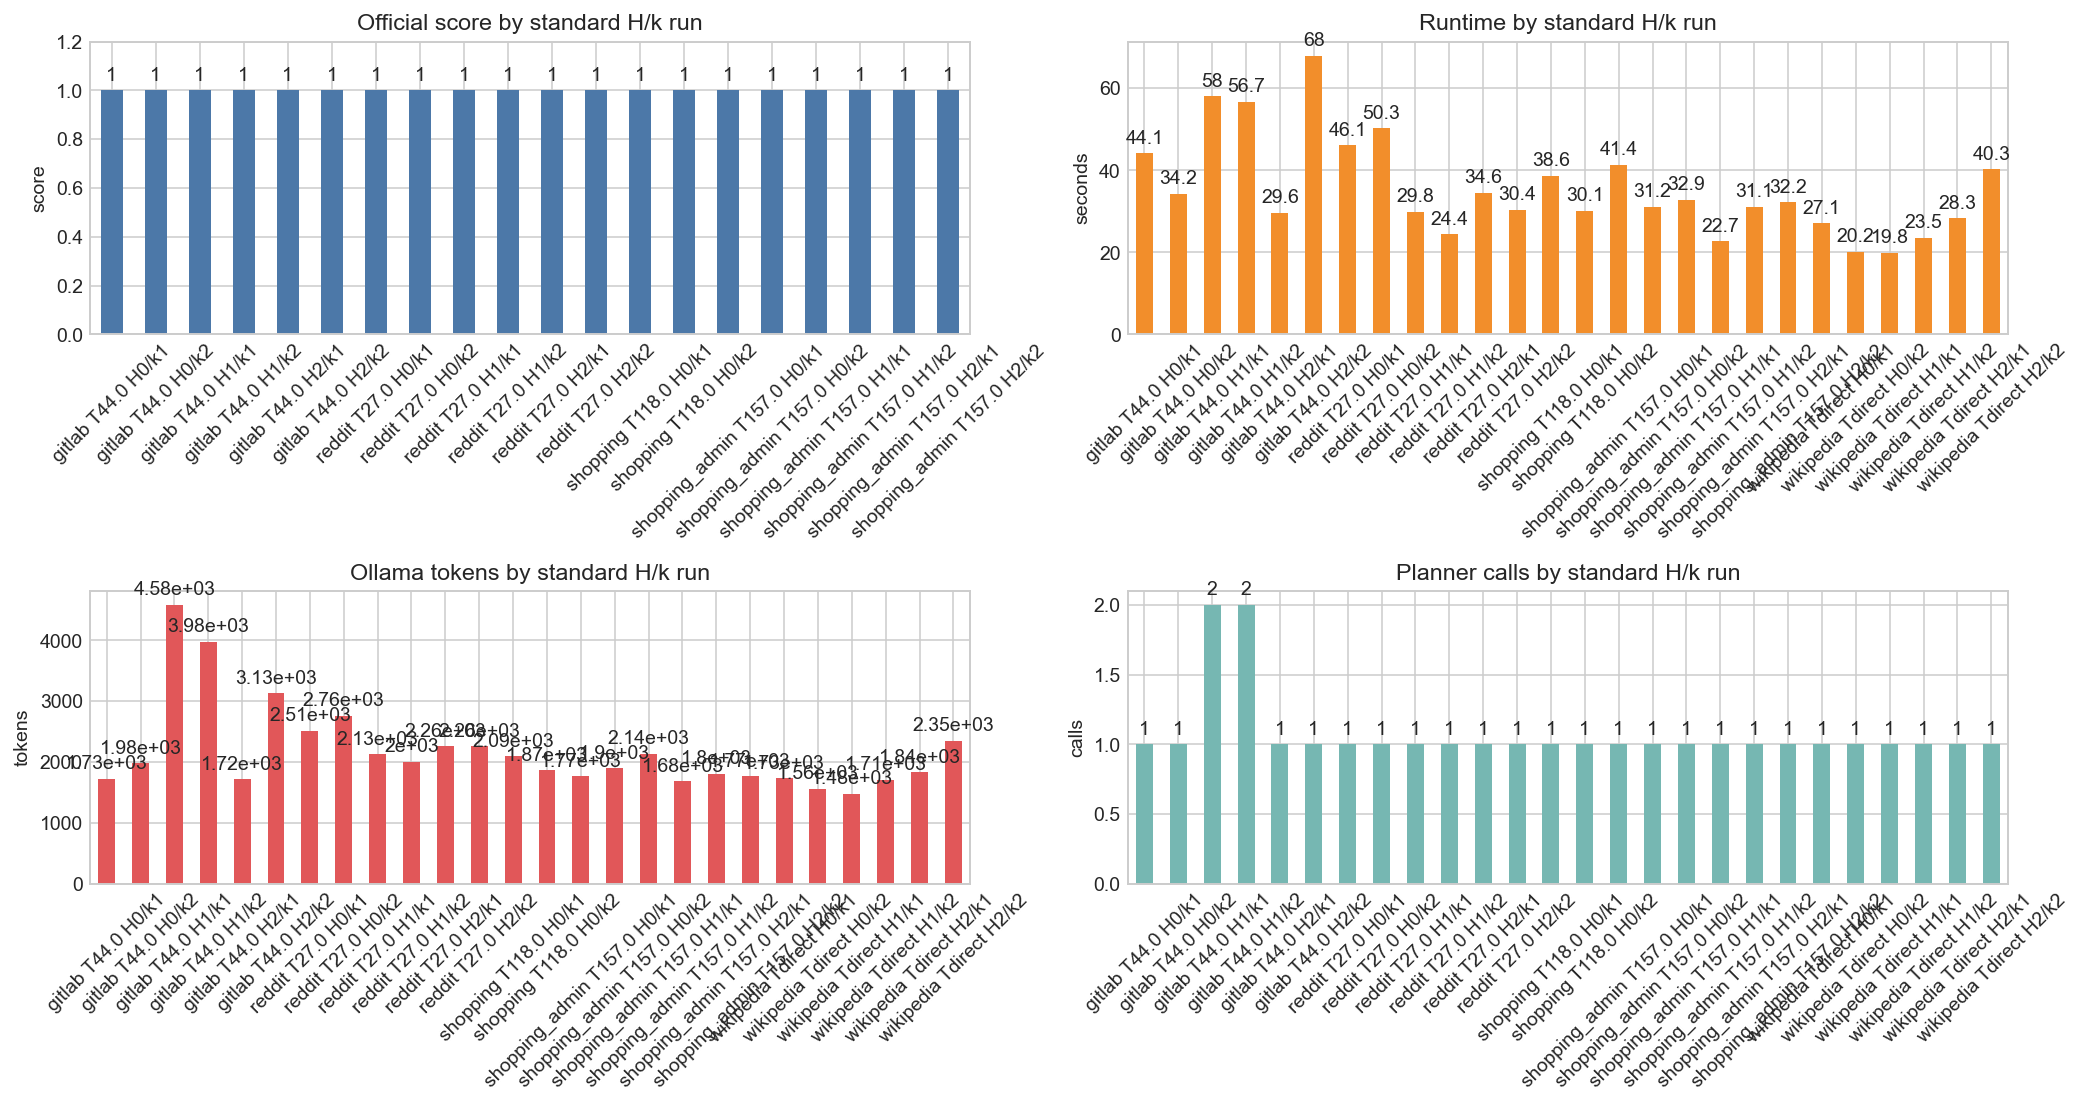

In [8]:
if standard_hk_df.empty:
    print('No standard H/k summaries found.')
else:
    cols = ['sweep_name', 'site', 'task_id', 'h', 'k', 'score', 'success', 'total_steps', 'num_planner_calls', 'num_plan_subgoals_generated', 'total_tokens', 'runtime_s', 'final_url']
    display(standard_hk_df[cols])

    scored = standard_hk_df[standard_hk_df['score'].notna()].copy()
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    if not scored.empty:
        show_bar(axes[0, 0], scored.set_index('run_label')['score'], 'Official score by standard H/k run', ylabel='score', ylim=(0, 1.2), color='#4c78a8')
    show_bar(axes[0, 1], standard_hk_df.set_index('run_label')['runtime_s'], 'Runtime by standard H/k run', ylabel='seconds', color='#f28e2b')
    show_bar(axes[1, 0], standard_hk_df.set_index('run_label')['total_tokens'], 'Ollama tokens by standard H/k run', ylabel='tokens', color='#e15759')
    show_bar(axes[1, 1], standard_hk_df.set_index('run_label')['num_planner_calls'], 'Planner calls by standard H/k run', ylabel='calls', color='#76b7b2')
    for ax in axes.ravel():
        ax.tick_params(axis='x', labelrotation=45)
    plt.tight_layout()

## GitLab Task 44 Detail

,h,k,score,total_steps,num_planner_calls,total_tokens,runtime_s
0,0,1,1.0,2,1,1729,44.142
1,0,2,1.0,2,1,1978,34.199
2,1,1,1.0,2,2,4582,58.022
3,1,2,1.0,2,2,3979,56.731
4,2,1,1.0,2,1,1717,29.643
5,2,2,1.0,2,1,3130,67.989


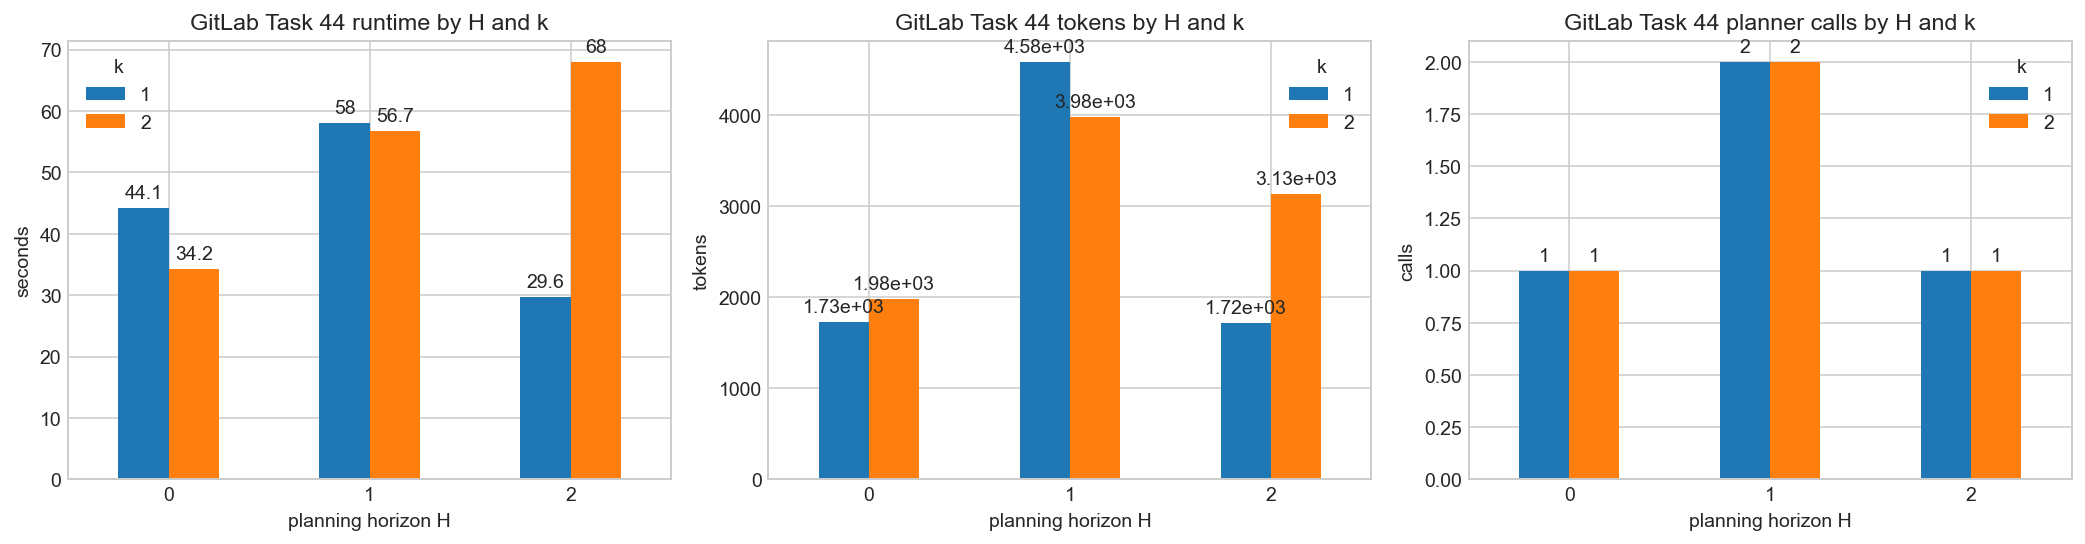

In [9]:
gitlab44_df = standard_hk_df[(standard_hk_df['site'] == 'gitlab') & (standard_hk_df['task_id'] == 44)].copy() if not standard_hk_df.empty else pd.DataFrame()
if gitlab44_df.empty:
    print('No GitLab Task 44 H/k rows found.')
else:
    display(gitlab44_df[['h', 'k', 'score', 'total_steps', 'num_planner_calls', 'total_tokens', 'runtime_s']])
    pivot_runtime = gitlab44_df.pivot(index='h', columns='k', values='runtime_s')
    pivot_tokens = gitlab44_df.pivot(index='h', columns='k', values='total_tokens')
    pivot_calls = gitlab44_df.pivot(index='h', columns='k', values='num_planner_calls')
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, pivot, title, ylabel in [
        (axes[0], pivot_runtime, 'GitLab Task 44 runtime by H and k', 'seconds'),
        (axes[1], pivot_tokens, 'GitLab Task 44 tokens by H and k', 'tokens'),
        (axes[2], pivot_calls, 'GitLab Task 44 planner calls by H and k', 'calls'),
    ]:
        pivot.plot(kind='bar', ax=ax, rot=0)
        ax.set_title(title)
        ax.set_xlabel('planning horizon H')
        ax.set_ylabel(ylabel)
        ax.legend(title='k')
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3g', padding=3)
    plt.tight_layout()

## Shopping Task 118 Detail: k As Action-Level Validation

Shopping H0/k1 step trace
Shopping H0/k1 evaluator signals
Shopping H0/k2 step trace
Shopping H0/k2 evaluator signals


,h,k,score,total_steps,num_planner_calls,total_tokens,runtime_s,output_dir
18,0,1,1.0,2,1,2094,38.638,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping/gemma4-26b/h0_k1/118
19,0,2,1.0,2,1,1869,30.072,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping/gemma4-26b/h0_k2/118


,step_index,subgoal_id,action,url_before,url_after,status
0,0,sg1,env.reset,NaN,http://localhost:7770/,success
1,1,sg1,"goto(""http://localhost:7770/catalogsearch/result/?q=mouth+guard"")",http://localhost:7770/,http://localhost:7770/catalogsearch/result/?q=mouth+guard,success
2,2,sg1,"goto(""http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-s...",http://localhost:7770/catalogsearch/result/?q=mouth+guard,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...,success


,step_index,subgoal_id,progress_score,subgoal_done,reason,recommended_intervention
0,1,sg1,0.5,False,shopping_search_results_reached,continue
1,2,sg1,1.0,True,target_product_page_reached,continue


,step_index,subgoal_id,action,url_before,url_after,status
0,0,sg1,env.reset,NaN,http://localhost:7770/,success
1,1,sg1,"goto(""http://localhost:7770/catalogsearch/result/?q=mouth+guard"")",http://localhost:7770/,http://localhost:7770/catalogsearch/result/?q=mouth+guard,success
2,2,sg1,"goto(""http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-s...",http://localhost:7770/catalogsearch/result/?q=mouth+guard,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...,success


,step_index,subgoal_id,progress_score,subgoal_done,reason,recommended_intervention
0,2,sg1,1.0,True,target_product_page_reached,continue


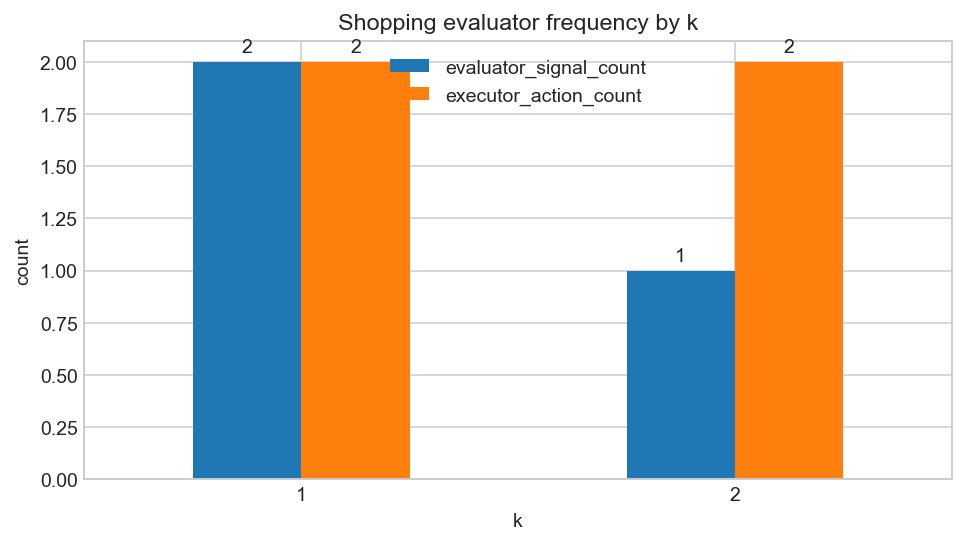

In [10]:
shopping_df = standard_hk_df[(standard_hk_df['site'] == 'shopping') & (standard_hk_df['task_id'] == 118)].copy() if not standard_hk_df.empty else pd.DataFrame()
if shopping_df.empty:
    print('No Shopping Task 118 H/k rows found.')
else:
    display(shopping_df[['h', 'k', 'score', 'total_steps', 'num_planner_calls', 'total_tokens', 'runtime_s', 'output_dir']])
    signal_rows = []
    for _, row in shopping_df.iterrows():
        signals = read_jsonl(artifact_paths(row['output_dir'])['evaluator_signals'])
        steps = read_jsonl(artifact_paths(row['output_dir'])['step_trace'])
        signal_rows.append({'k': row['k'], 'evaluator_signal_count': len(signals), 'executor_action_count': max(len(steps) - 1, 0)})
        print(f"Shopping H{row['h']}/k{row['k']} step trace")
        display(steps[['step_index', 'subgoal_id', 'action', 'url_before', 'url_after', 'status']])
        print(f"Shopping H{row['h']}/k{row['k']} evaluator signals")
        display(signals[['step_index', 'subgoal_id', 'progress_score', 'subgoal_done', 'reason', 'recommended_intervention']])
    signal_df = pd.DataFrame(signal_rows).set_index('k').sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    signal_df.plot(kind='bar', ax=ax, rot=0)
    ax.set_title('Shopping evaluator frequency by k')
    ax.set_xlabel('k')
    ax.set_ylabel('count')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3)
    plt.tight_layout()

## Per-Site H/k Charts

Each currently executable H/k site gets its own chart set. This makes site-specific behavior easier to inspect than the combined overview chart.

,site,task_id,h,k,score,success,runtime_s,total_tokens,num_planner_calls,output_dir
0,gitlab,44.0,0,1,1.0,True,44.142,1729,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h0_k1/44
1,gitlab,44.0,0,2,1.0,True,34.199,1978,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h0_k2/44
2,gitlab,44.0,1,1,1.0,True,58.022,4582,2,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h1_k1/44
3,gitlab,44.0,1,2,1.0,True,56.731,3979,2,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h1_k2/44
4,gitlab,44.0,2,1,1.0,True,29.643,1717,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h2_k1/44
5,gitlab,44.0,2,2,1.0,True,67.989,3130,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h2_k2/44


,site,task_id,h,k,score,success,runtime_s,total_tokens,num_planner_calls,output_dir
18,shopping,118.0,0,1,1.0,True,38.638,2094,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping/gemma4-26b/h0_k1/118
19,shopping,118.0,0,2,1.0,True,30.072,1869,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping/gemma4-26b/h0_k2/118


,site,task_id,h,k,score,success,runtime_s,total_tokens,num_planner_calls,output_dir
20,shopping_admin,157.0,0,1,1.0,True,41.389,1770,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping_admin/gemma4-26b/h0_k1/157
21,shopping_admin,157.0,0,2,1.0,True,31.171,1900,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping_admin/gemma4-26b/h0_k2/157
22,shopping_admin,157.0,1,1,1.0,True,32.880,2136,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping_admin/gemma4-26b/h1_k1/157
23,shopping_admin,157.0,1,2,1.0,True,22.697,1684,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping_admin/gemma4-26b/h1_k2/157
24,shopping_admin,157.0,2,1,1.0,True,31.095,1804,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping_admin/gemma4-26b/h2_k1/157
25,shopping_admin,157.0,2,2,1.0,True,32.173,1766,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping_admin/gemma4-26b/h2_k2/157


,site,task_id,h,k,score,success,runtime_s,total_tokens,num_planner_calls,output_dir
12,reddit,27.0,0,1,1.0,True,46.069,2513,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/reddit/gemma4-26b/h0_k1/27
13,reddit,27.0,0,2,1.0,True,50.252,2757,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/reddit/gemma4-26b/h0_k2/27
14,reddit,27.0,1,1,1.0,True,29.848,2126,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/reddit/gemma4-26b/h1_k1/27
15,reddit,27.0,1,2,1.0,True,24.398,2001,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/reddit/gemma4-26b/h1_k2/27
16,reddit,27.0,2,1,1.0,True,34.564,2263,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/reddit/gemma4-26b/h2_k1/27
17,reddit,27.0,2,2,1.0,True,30.407,2263,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/reddit/gemma4-26b/h2_k2/27


,site,task_id,h,k,score,success,runtime_s,total_tokens,num_planner_calls,output_dir
26,wikipedia,NaN,0,1,NaN,None,27.093,1732,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/wikipedia/gemma4-26b/h0_k1/direct
27,wikipedia,NaN,0,2,NaN,None,20.151,1564,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/wikipedia/gemma4-26b/h0_k2/direct
28,wikipedia,NaN,1,1,NaN,None,19.818,1484,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/wikipedia/gemma4-26b/h1_k1/direct
29,wikipedia,NaN,1,2,NaN,None,23.527,1710,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/wikipedia/gemma4-26b/h1_k2/direct
30,wikipedia,NaN,2,1,NaN,None,28.283,1836,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/wikipedia/gemma4-26b/h2_k1/direct
31,wikipedia,NaN,2,2,NaN,None,40.282,2350,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/wikipedia/gemma4-26b/h2_k2/direct


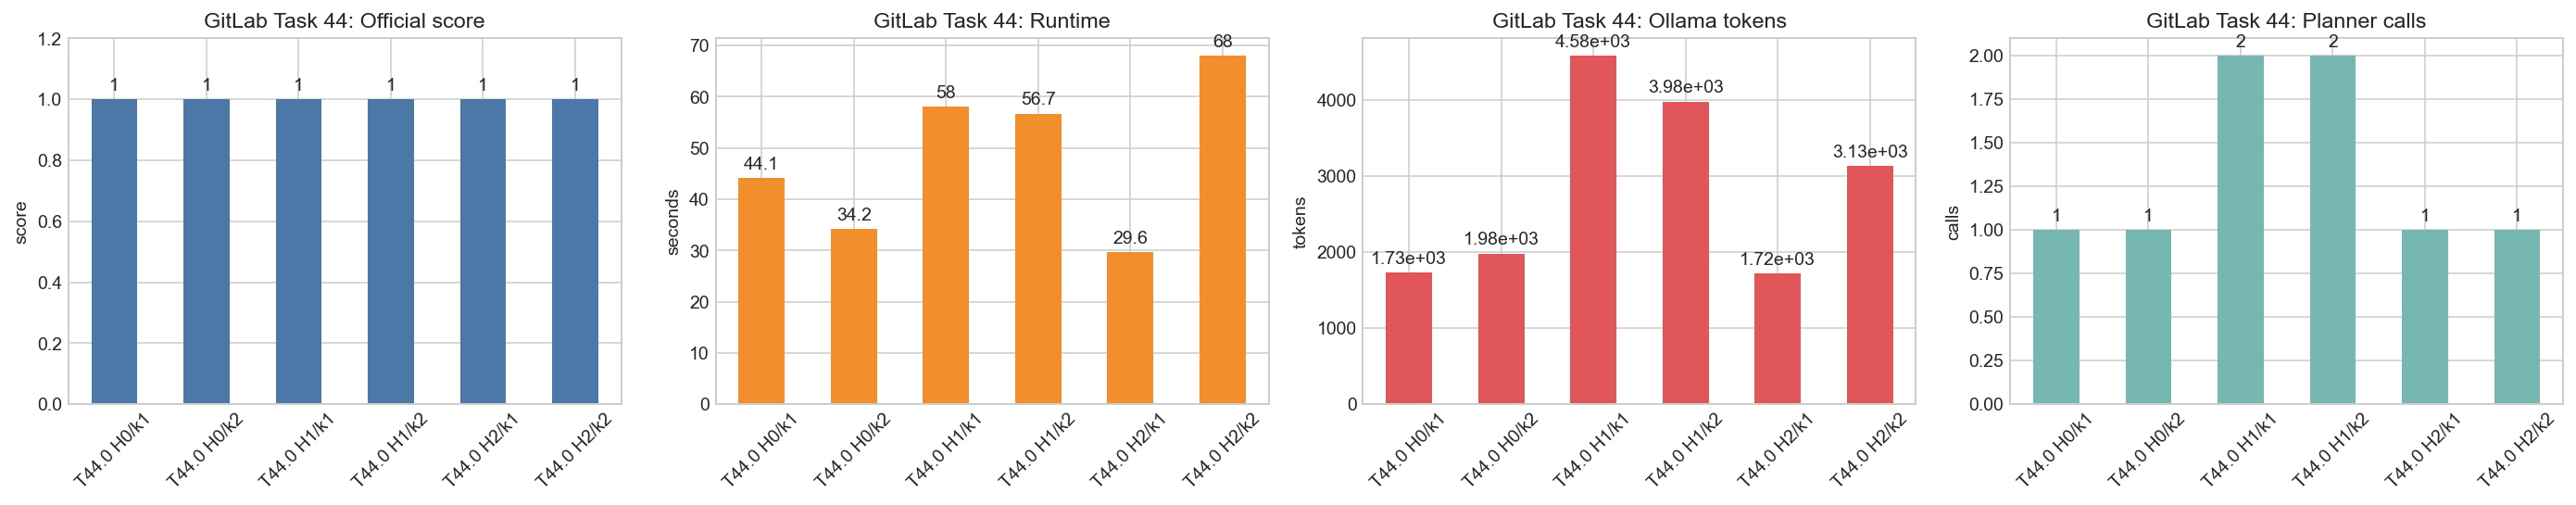

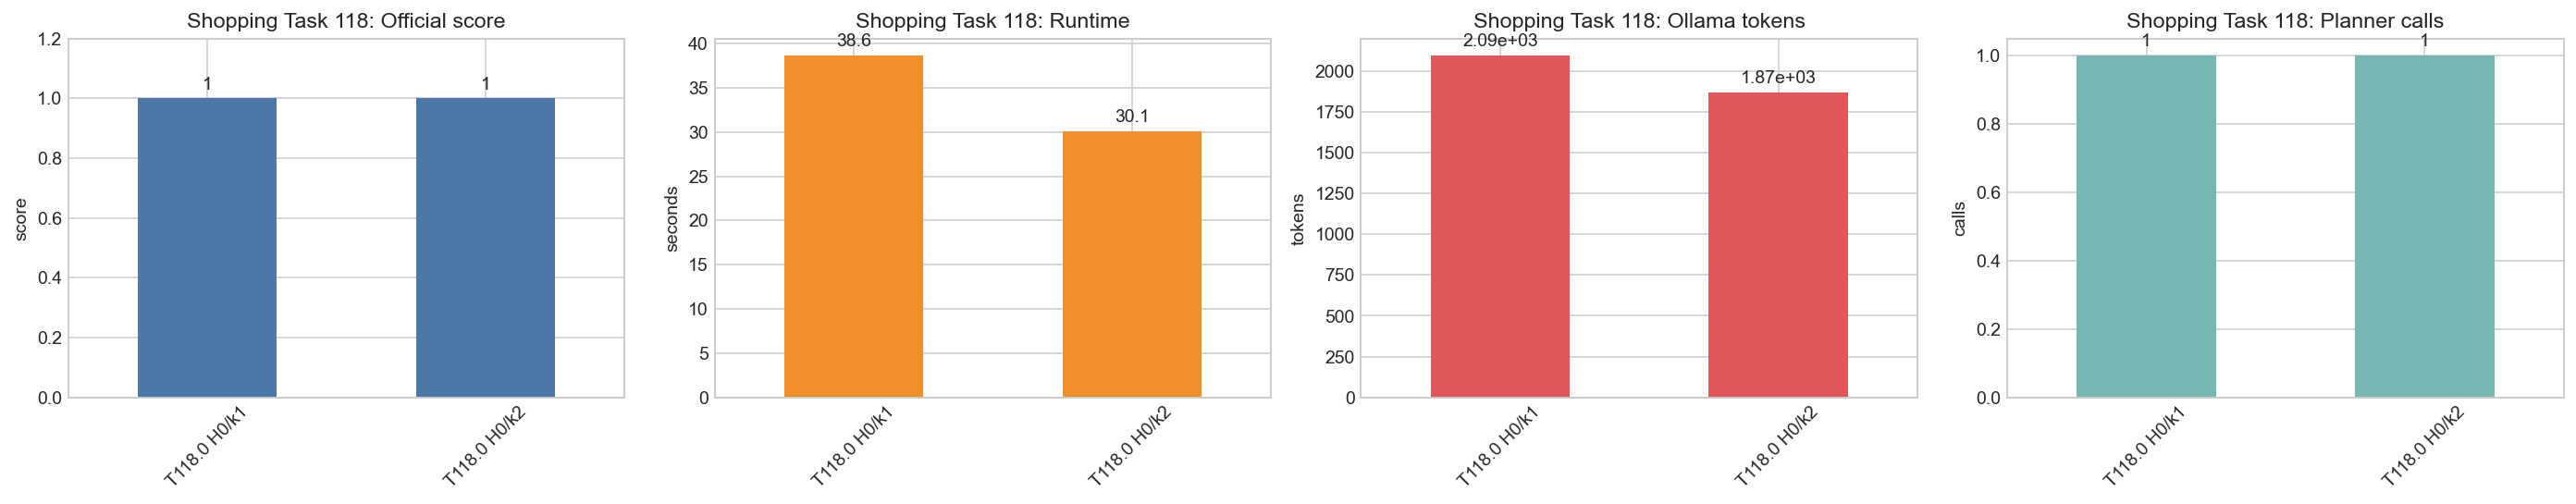

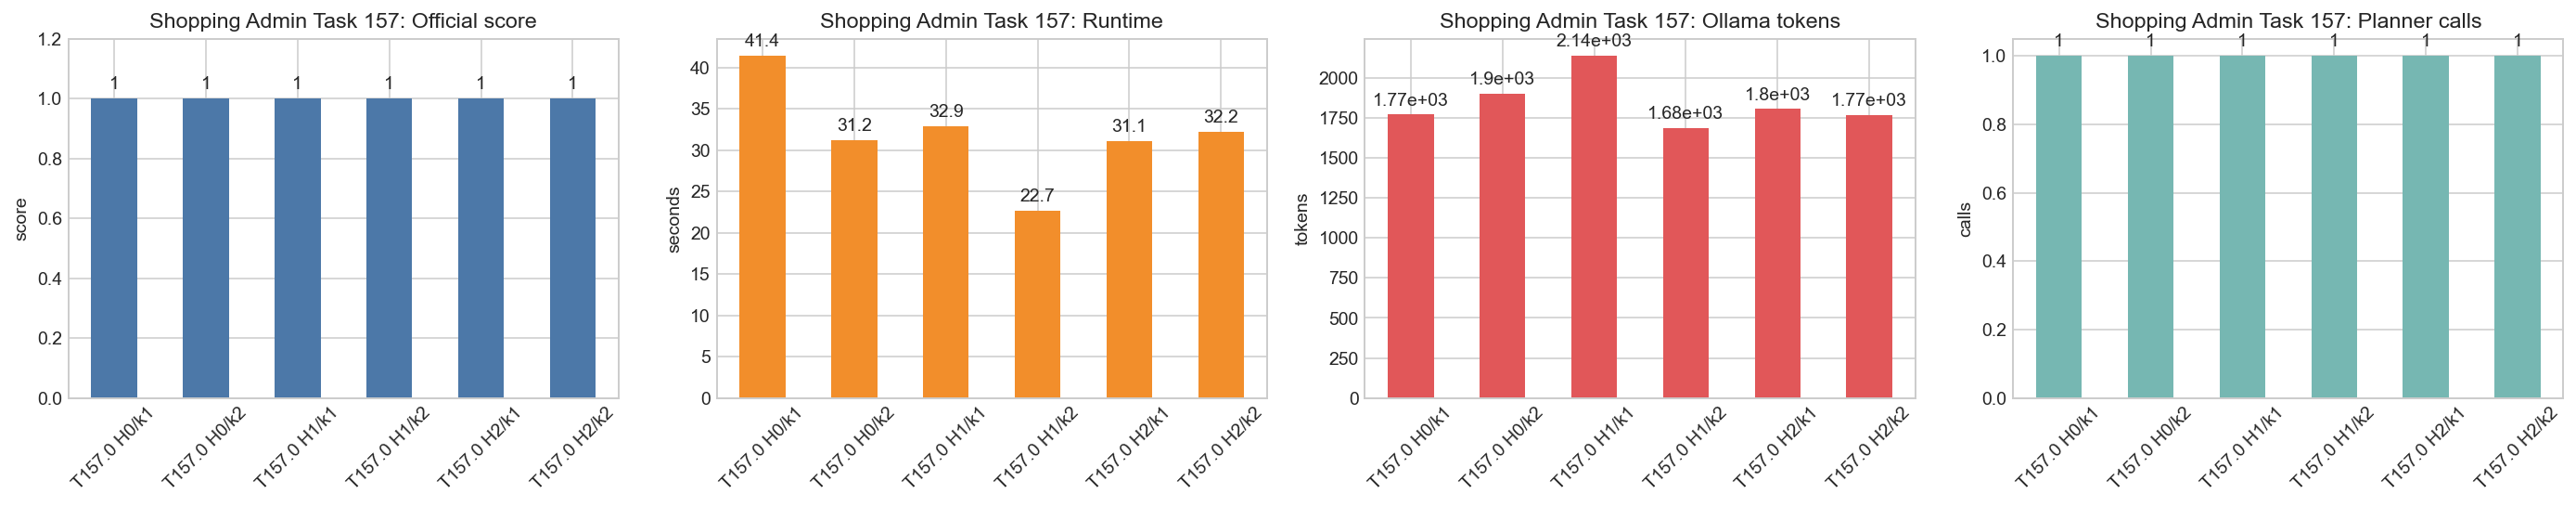

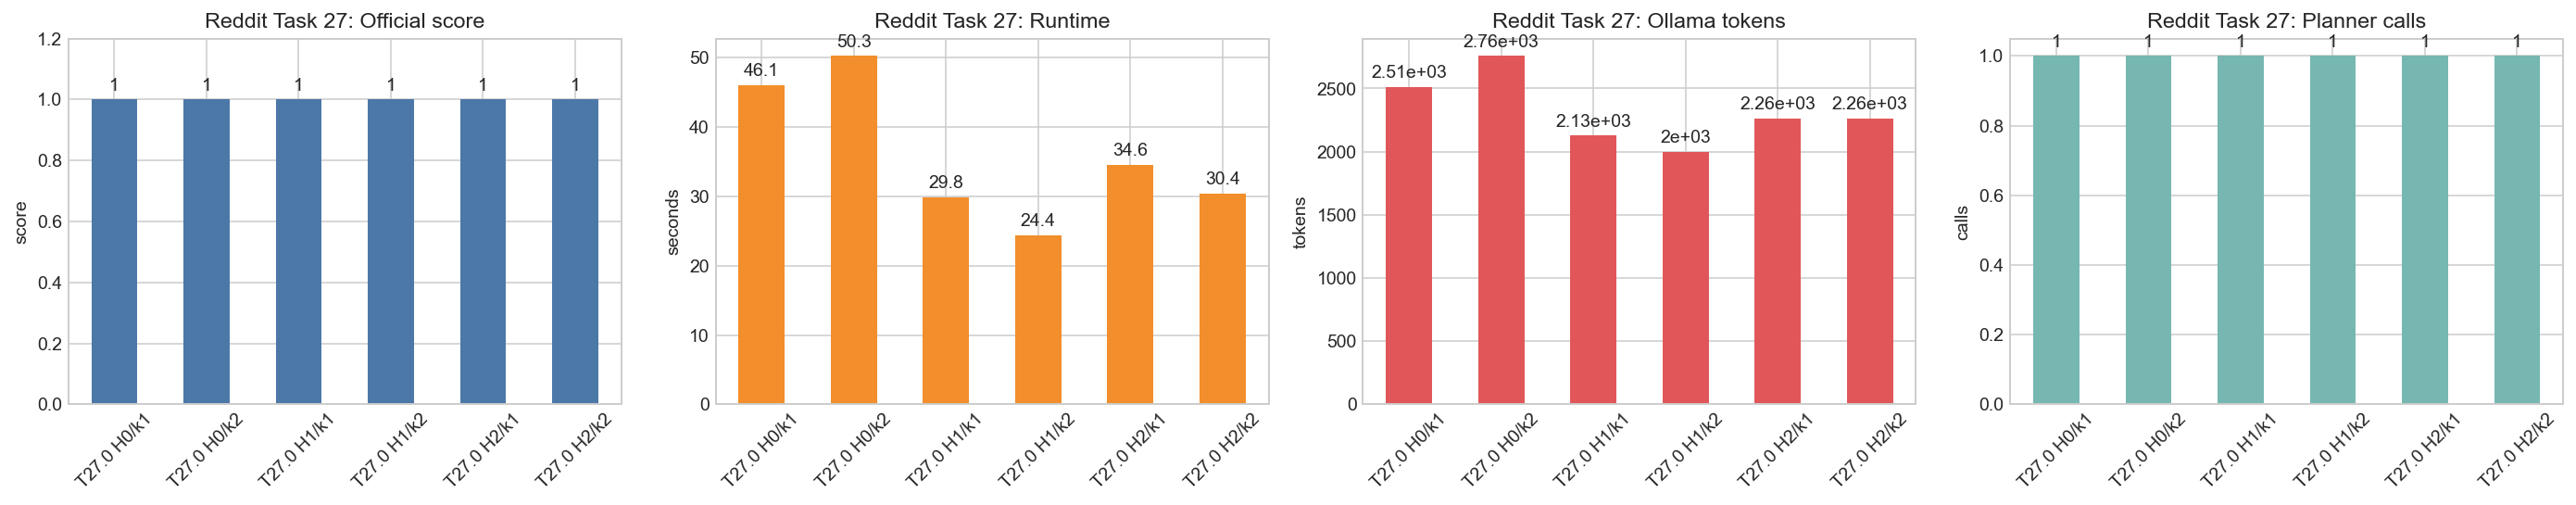

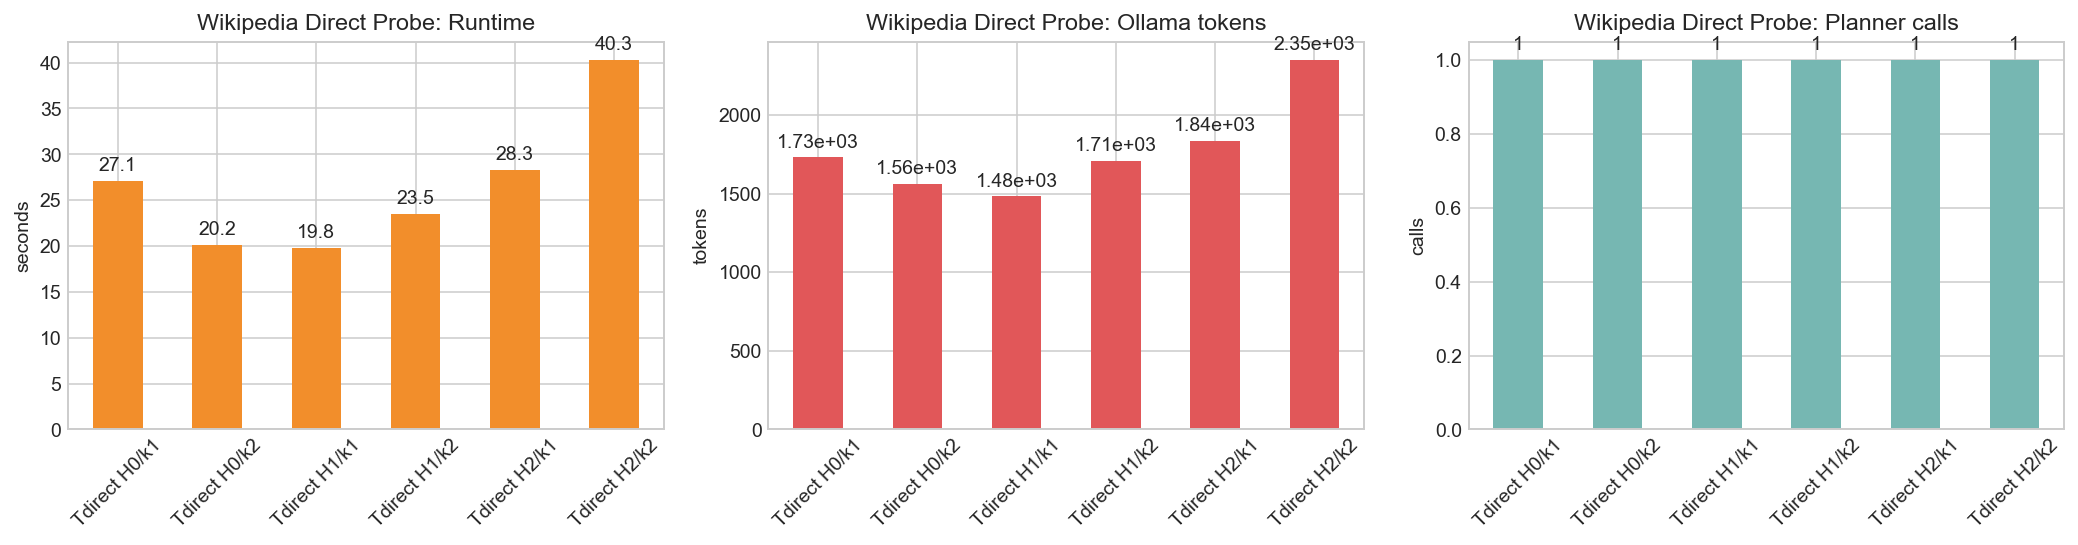

In [11]:
def plot_site_hk(site_df: pd.DataFrame, title: str, include_score: bool = True):
    if site_df.empty:
        print(f'No rows for {title}')
        return
    site_df = site_df.copy().sort_values(['task_id', 'h', 'k'])
    site_df['local_label'] = 'T' + site_df['task_label'] + ' H' + site_df['h'].astype(str) + '/k' + site_df['k'].astype(str)
    metric_specs = []
    if include_score and site_df['score'].notna().any():
        metric_specs.append(('score', 'Official score', 'score', '#4c78a8', (0, 1.2)))
    metric_specs.extend([
        ('runtime_s', 'Runtime', 'seconds', '#f28e2b', None),
        ('total_tokens', 'Ollama tokens', 'tokens', '#e15759', None),
        ('num_planner_calls', 'Planner calls', 'calls', '#76b7b2', None),
    ])

    fig, axes = plt.subplots(1, len(metric_specs), figsize=(5 * len(metric_specs), 4))
    if len(metric_specs) == 1:
        axes = [axes]
    for ax, (column, metric_title, ylabel, color, ylim) in zip(axes, metric_specs):
        show_bar(
            ax,
            site_df.set_index('local_label')[column],
            f'{title}: {metric_title}',
            ylabel=ylabel,
            ylim=ylim,
            color=color,
        )
        ax.tick_params(axis='x', labelrotation=45)
    plt.tight_layout()

site_chart_specs = [
    ('gitlab', 44, 'GitLab Task 44', True),
    ('shopping', 118, 'Shopping Task 118', True),
    ('shopping_admin', 157, 'Shopping Admin Task 157', True),
    ('reddit', 27, 'Reddit Task 27', True),
    ('wikipedia', None, 'Wikipedia Direct Probe', False),
]

for site, task_id, title, include_score in site_chart_specs:
    subset = standard_hk_df[standard_hk_df['site'] == site].copy() if not standard_hk_df.empty else pd.DataFrame()
    if task_id is None:
        subset = subset[subset['task_id'].isna()] if not subset.empty else subset
    else:
        subset = subset[subset['task_id'] == task_id] if not subset.empty else subset
    display(subset[['site', 'task_id', 'h', 'k', 'score', 'success', 'runtime_s', 'total_tokens', 'num_planner_calls', 'output_dir']] if not subset.empty else pd.DataFrame())
    plot_site_hk(subset, title, include_score=include_score)

## Longer GitLab Candidate: Task 105

Task 105 was selected from the local WebArena-Verified GitLab task set as a longer Navigate-style task:

`Navigate to the page showing the list of not yet closed issues in the OpenAPITools/openapi-generator repository that have labels related to OpenAPI Generator CLI`

The H/k pipeline can execute it and produce runtime/token/planner-call measurements. However, in the current local demo GitLab instance the expected repository/issues URL returns 404, so official WebArena-Verified score is 0. This is still useful as a negative environment-coverage finding, but not yet a valid success-rate benchmark.

,h,k,score,success,total_steps,num_planner_calls,total_tokens,runtime_s,final_url
6,0,1,0.0,False,2,1,2546,42.348,http://localhost:8012/OpenAPITools/openapi-generator/-/issues
7,0,2,0.0,False,2,1,3237,51.887,http://localhost:8012/OpenAPITools/openapi-generator/-/issues
8,1,1,0.0,False,3,2,6420,92.390,http://localhost:8012/OpenAPITools/openapi-generator/-/issues
9,1,2,0.0,False,2,2,5304,89.003,http://localhost:8012/OpenAPITools/openapi-generator/-/issues
10,2,1,0.0,False,2,1,2348,41.729,http://localhost:8012/OpenAPITools/openapi-generator/-/issues
11,2,2,0.0,False,2,1,2441,42.373,http://localhost:8012/OpenAPITools/openapi-generator/-/issues


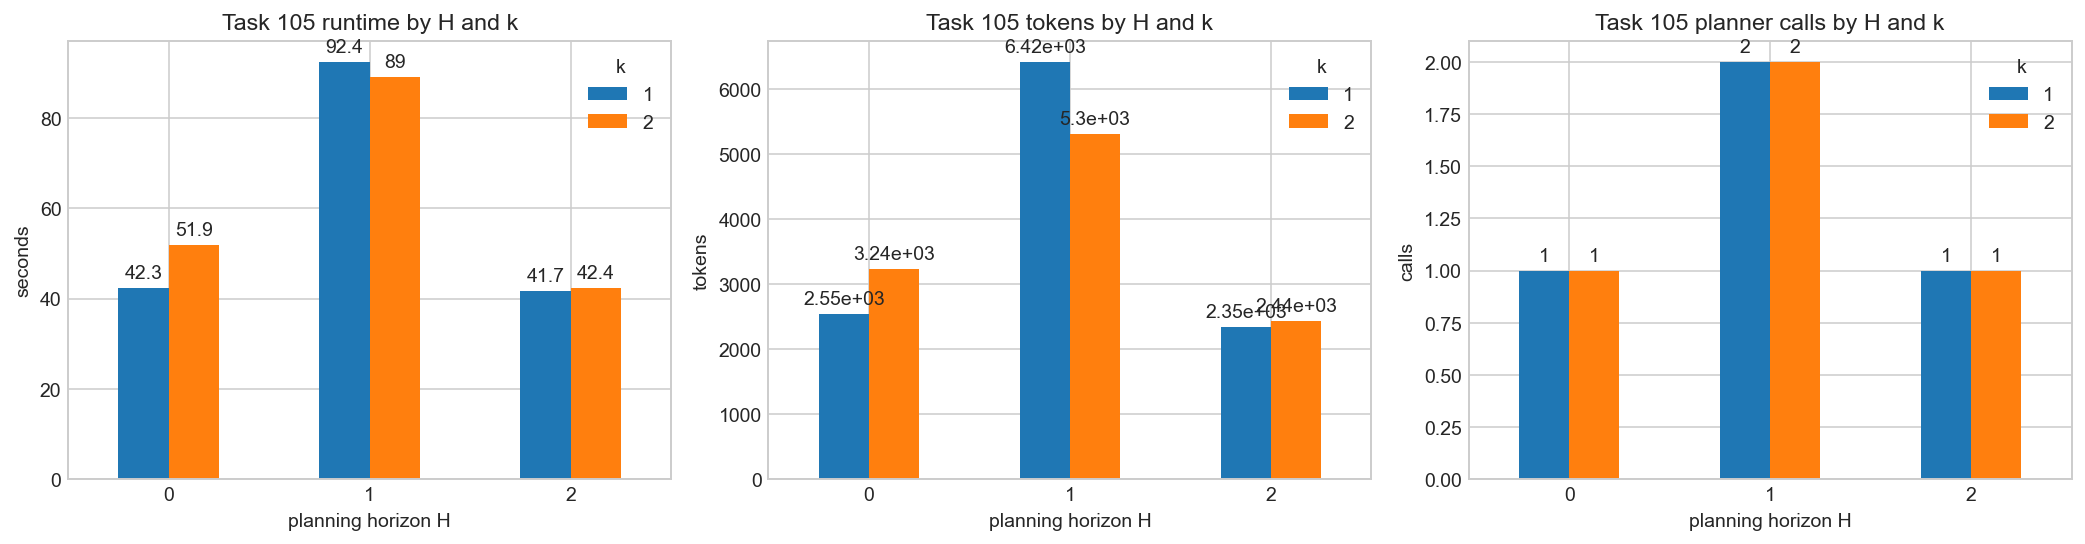

In [12]:
if long_gitlab_df.empty:
    print('No GitLab Task 105 rows found. Run RUN_LONG_GITLAB_CANDIDATE = True to generate them.')
else:
    display(long_gitlab_df[['h', 'k', 'score', 'success', 'total_steps', 'num_planner_calls', 'total_tokens', 'runtime_s', 'final_url']])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    long_gitlab_df.pivot(index='h', columns='k', values='runtime_s').plot(kind='bar', ax=axes[0], rot=0)
    axes[0].set_title('Task 105 runtime by H and k')
    axes[0].set_ylabel('seconds')
    long_gitlab_df.pivot(index='h', columns='k', values='total_tokens').plot(kind='bar', ax=axes[1], rot=0)
    axes[1].set_title('Task 105 tokens by H and k')
    axes[1].set_ylabel('tokens')
    long_gitlab_df.pivot(index='h', columns='k', values='num_planner_calls').plot(kind='bar', ax=axes[2], rot=0)
    axes[2].set_title('Task 105 planner calls by H and k')
    axes[2].set_ylabel('calls')
    for ax in axes:
        ax.set_xlabel('planning horizon H')
        ax.legend(title='k')
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3g', padding=3)
    plt.tight_layout()

## Interpretation Snapshot

In [13]:
checks = {
    'service_probe_all_success': bool(not service_df.empty and (service_df['status'] == 'success').all()),
    'hardcoded_all_official_score_1': bool(not hardcoded_df.empty and (hardcoded_df['official_score'] == 1.0).all()),
    'planner_preview_all_sites_present': set(SITE_ORDER).issubset(set(preview_df.get('site', []))),
    'standard_hk_official_scores_all_1_excluding_wikipedia': bool(not standard_hk_df.empty and (standard_hk_df[standard_hk_df['site'].isin(OFFICIAL_HK_SITES)]['score'] == 1.0).all()),
    'wikipedia_hk_probe_present_without_official_score': bool(not standard_hk_df.empty and ((standard_hk_df['site'] == 'wikipedia') & standard_hk_df['score'].isna()).any()),
    'reddit_hk_present_with_official_score': bool(not standard_hk_df.empty and ((standard_hk_df['site'] == 'reddit') & (standard_hk_df['score'] == 1.0)).any()),
    'gitlab_task105_exploratory_negative_result_present': bool(not long_gitlab_df.empty and (long_gitlab_df['score'] == 0.0).any()),
}
for key, value in checks.items():
    print(f'{key}: {value}')

service_probe_all_success: True
hardcoded_all_official_score_1: False
planner_preview_all_sites_present: True
standard_hk_official_scores_all_1_excluding_wikipedia: True
wikipedia_hk_probe_present_without_official_score: True
reddit_hk_present_with_official_score: True
gitlab_task105_exploratory_negative_result_present: True
